[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/kkipngenokoech/Material-Science/blob/main/Laboratory%2003%20-%20Machine%20Learning/random_forest_cement.ipynb)

In [1]:
!wget -q "https://raw.githubusercontent.com/kkipngenokoech/Material-Science/main/Laboratory%2003%20-%20Machine%20Learning/dataset_cement.csv"

# Random Forest Regression

**Goal**: Identify the physical and chemical factors controlling the compressive strength of concrete samples

In [2]:
import numpy as np
import pandas as pd
from sklearn import model_selection
from sklearn.ensemble import RandomForestRegressor
from sklearn import tree
from sklearn.inspection import permutation_importance
from sklearn.inspection import PartialDependenceDisplay
from sklearn.inspection import partial_dependence
from matplotlib import pyplot as plt

Load the dataset. It contains one label (concrete compressive strength) and eight features per sample

In [3]:
df = pd.read_csv("./dataset_cement.csv")
df

,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.052780
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.296075
...,...,...,...,...,...,...,...,...,...
1025,276.4,116.0,90.3,179.6,8.9,870.1,768.3,28,44.284354
1026,322.2,0.0,115.6,196.0,10.4,817.9,813.4,28,31.178794
1027,148.5,139.4,108.6,192.7,6.1,892.4,780.0,28,23.696601
1028,159.1,186.7,0.0,175.6,11.3,989.6,788.9,28,32.768036


In [4]:
df.columns, df.shape[1], df.columns[:-1].tolist()

(Index(['Cement (component 1)(kg in a m^3 mixture)',
        'Blast Furnace Slag (component 2)(kg in a m^3 mixture)',
        'Fly Ash (component 3)(kg in a m^3 mixture)',
        'Water  (component 4)(kg in a m^3 mixture)',
        'Superplasticizer (component 5)(kg in a m^3 mixture)',
        'Coarse Aggregate  (component 6)(kg in a m^3 mixture)',
        'Fine Aggregate (component 7)(kg in a m^3 mixture)', 'Age (day)',
        'Concrete compressive strength(MPa, megapascals)'],
       dtype='object'),
 9,
 ['Cement (component 1)(kg in a m^3 mixture)',
  'Blast Furnace Slag (component 2)(kg in a m^3 mixture)',
  'Fly Ash (component 3)(kg in a m^3 mixture)',
  'Water  (component 4)(kg in a m^3 mixture)',
  'Superplasticizer (component 5)(kg in a m^3 mixture)',
  'Coarse Aggregate  (component 6)(kg in a m^3 mixture)',
  'Fine Aggregate (component 7)(kg in a m^3 mixture)',
  'Age (day)'])

## Pearson correlation

In [5]:
dir(df)

['T',
 '_AXIS_LEN',
 '_AXIS_ORDERS',
 '_AXIS_TO_AXIS_NUMBER',
 '_HANDLED_TYPES',
 '__abs__',
 '__add__',
 '__and__',
 '__annotations__',
 '__array__',
 '__array_priority__',
 '__array_ufunc__',
 '__arrow_c_stream__',
 '__bool__',
 '__class__',
 '__contains__',
 '__copy__',
 '__dataframe__',
 '__dataframe_consortium_standard__',
 '__deepcopy__',
 '__delattr__',
 '__delitem__',
 '__dict__',
 '__dir__',
 '__divmod__',
 '__doc__',
 '__eq__',
 '__finalize__',
 '__floordiv__',
 '__format__',
 '__ge__',
 '__getattr__',
 '__getattribute__',
 '__getitem__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__iadd__',
 '__iand__',
 '__ifloordiv__',
 '__imod__',
 '__imul__',
 '__init__',
 '__init_subclass__',
 '__invert__',
 '__ior__',
 '__ipow__',
 '__isub__',
 '__iter__',
 '__itruediv__',
 '__ixor__',
 '__le__',
 '__len__',
 '__lt__',
 '__matmul__',
 '__mod__',
 '__module__',
 '__mul__',
 '__ne__',
 '__neg__',
 '__new__',
 '__nonzero__',
 '__or__',
 '__pandas_priority__',
 '__pos__',
 '__pow__',
 '__r

In [6]:
help(df.corr)

Help on method corr in module pandas.core.frame:

corr(method: 'CorrelationMethod' = 'pearson', min_periods: 'int' = 1, numeric_only: 'bool' = False) -> 'DataFrame' method of pandas.core.frame.DataFrame instance
    Compute pairwise correlation of columns, excluding NA/null values.

    Parameters
    ----------
    method : {'pearson', 'kendall', 'spearman'} or callable
        Method of correlation:

        * pearson : standard correlation coefficient
        * kendall : Kendall Tau correlation coefficient
        * spearman : Spearman rank correlation
        * callable: callable with input two 1d ndarrays
            and returning a float. Note that the returned matrix from corr
            will have 1 along the diagonals and will be symmetric
            regardless of the callable's behavior.
    min_periods : int, optional
        Minimum number of observations required per pair of columns
        to have a valid result. Currently only available for Pearson
        and Spearman 

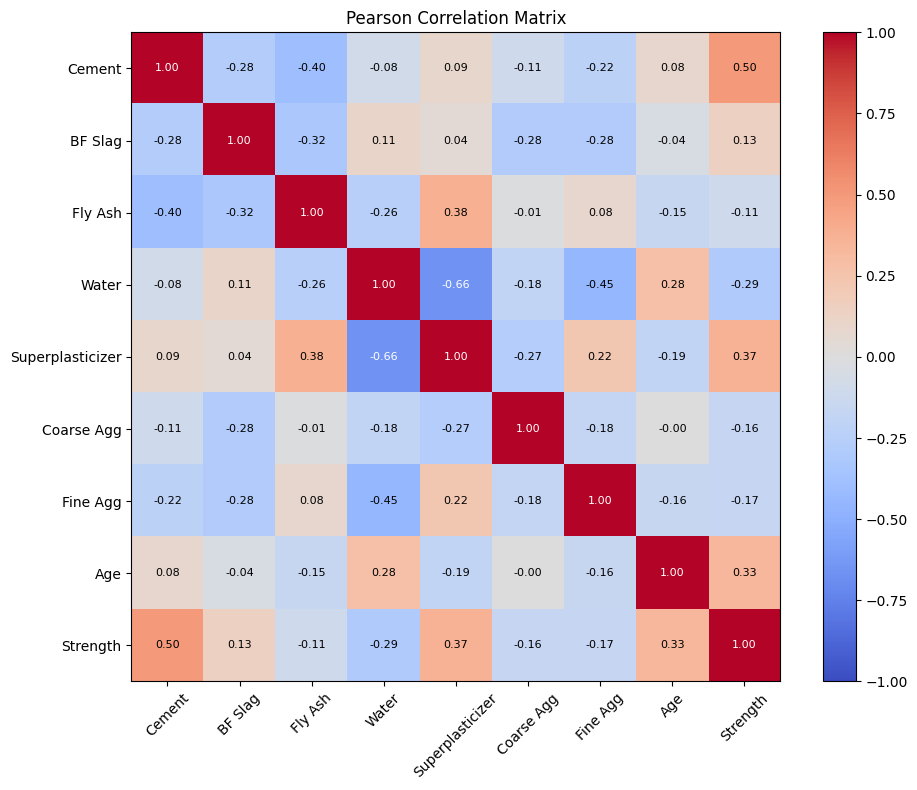

In [7]:
labels = ["Cement", "BF Slag", "Fly Ash", "Water", "Superplasticizer",
          "Coarse Agg", "Fine Agg", "Age", "Strength"]

corr = df.corr(method="pearson")

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr.values, vmin=-1, vmax=1, cmap="coolwarm")
plt.colorbar(im, ax=ax)

ax.set(xticks=range(len(labels)), xticklabels=labels,
       yticks=range(len(labels)), yticklabels=labels,
       title="Pearson Correlation Matrix")
ax.tick_params(axis="x", rotation=45)

for (i, j), val in np.ndenumerate(corr.values):
    ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=8,
            color="white" if abs(val) > 0.6 else "black")

plt.tight_layout()
plt.show()


In [8]:
corr_features = corr.iloc[:-1, :-1]
np.fill_diagonal(corr_features.values, 0)  # zero out the diagonal
max_idx = np.unravel_index(np.argmax(np.abs(corr_features.values)), corr_features.shape)
feat1, feat2 = labels[max_idx[0]], labels[max_idx[1]]
print(f"Most correlated pair: '{feat1}' & '{feat2}'  (r = {corr_features.values[max_idx]:.3f})")


Most correlated pair: 'Water' & 'Superplasticizer'  (r = -0.657)


In [9]:
corr_features = corr.iloc[:-1, :-1]
unstacked = corr_features.abs().unstack()
pair = unstacked[unstacked < 1].idxmax()
print(f"Most correlated pair: '{pair[0]}' & '{pair[1]}'  (r = {corr_features.loc[pair]:.3f})")


Most correlated pair: 'Water  (component 4)(kg in a m^3 mixture)' & 'Superplasticizer (component 5)(kg in a m^3 mixture)'  (r = -0.657)


## Random Forest Regression


In [10]:
X = df.drop(columns=[df.columns[-1]]).values
y = df[df.columns[-1]].values

X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_train = rf.predict(X_train)
y_pred_test  = rf.predict(X_test)

In [11]:
rmse_train = np.sqrt(np.mean((y_pred_train - y_train) ** 2))
rmse_test  = np.sqrt(np.mean((y_pred_test  - y_test)  ** 2))

print(f"Train RMSE: {rmse_train:.3f}")
print(f"Test RMSE:  {rmse_test:.3f}")

from sklearn.metrics import root_mean_squared_error

rmse_train = root_mean_squared_error(y_train, y_pred_train)
rmse_test  = root_mean_squared_error(y_test,  y_pred_test)
print(f"Train RMSE: {rmse_train:.3f}")
print(f"Test RMSE:  {rmse_test:.3f}")

Train RMSE: 1.952
Test RMSE:  5.459
Train RMSE: 1.952
Test RMSE:  5.459


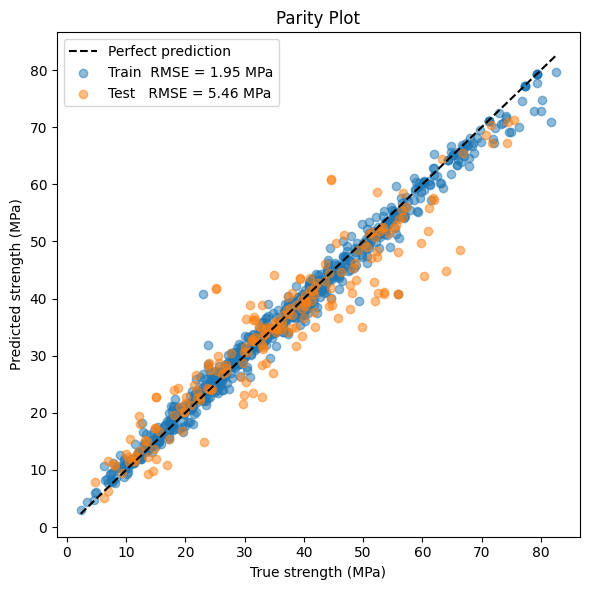

In [12]:
# Parity plot
lims = [y.min(), y.max()]
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(lims, lims, "--", color="black", label="Perfect prediction")
ax.scatter(y_train, y_pred_train, alpha=0.5, label=f"Train  RMSE = {rmse_train:.2f} MPa")
ax.scatter(y_test,  y_pred_test,  alpha=0.5, label=f"Test   RMSE = {rmse_test:.2f} MPa")
ax.set(xlabel="True strength (MPa)", ylabel="Predicted strength (MPa)", title="Parity Plot")
ax.legend()
plt.tight_layout()
plt.show()


## Importance ranking

In [15]:
dir(rf)

['__abstractmethods__',
 '__annotations__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getitem__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__iter__',
 '__le__',
 '__len__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__setstate__',
 '__sizeof__',
 '__sklearn_clone__',
 '__sklearn_tags__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_abc_impl',
 '_build_request_for_signature',
 '_check_feature_names',
 '_check_n_features',
 '_compute_oob_predictions',
 '_compute_partial_dependence_recursion',
 '_doc_link_module',
 '_doc_link_template',
 '_doc_link_url_param_generator',
 '_estimator_type',
 '_get_default_requests',
 '_get_doc_link',
 '_get_estimators_indices',
 '_get_metadata_request',
 '_get_oob_predictions',
 '_get_param_names',
 '_get_tags',
 '_make_estimator',
 '_more_tags',
 '_n_samples

In [16]:
? rf.feature_importances_

Type:        property
String form: <property object at 0x7f6044a25f30>
Docstring:  
The impurity-based feature importances.

The higher, the more important the feature.
The importance of a feature is computed as the (normalized)
total reduction of the criterion brought by that feature.  It is also
known as the Gini importance.

high cardinality features (many unique values). See
:func:`sklearn.inspection.permutation_importance` as an alternative.

Returns
-------
feature_importances_ : ndarray of shape (n_features,)
    The values of this array sum to 1, unless all trees are single node
    trees consisting of only the root node, in which case it will be an
    array of zeros.


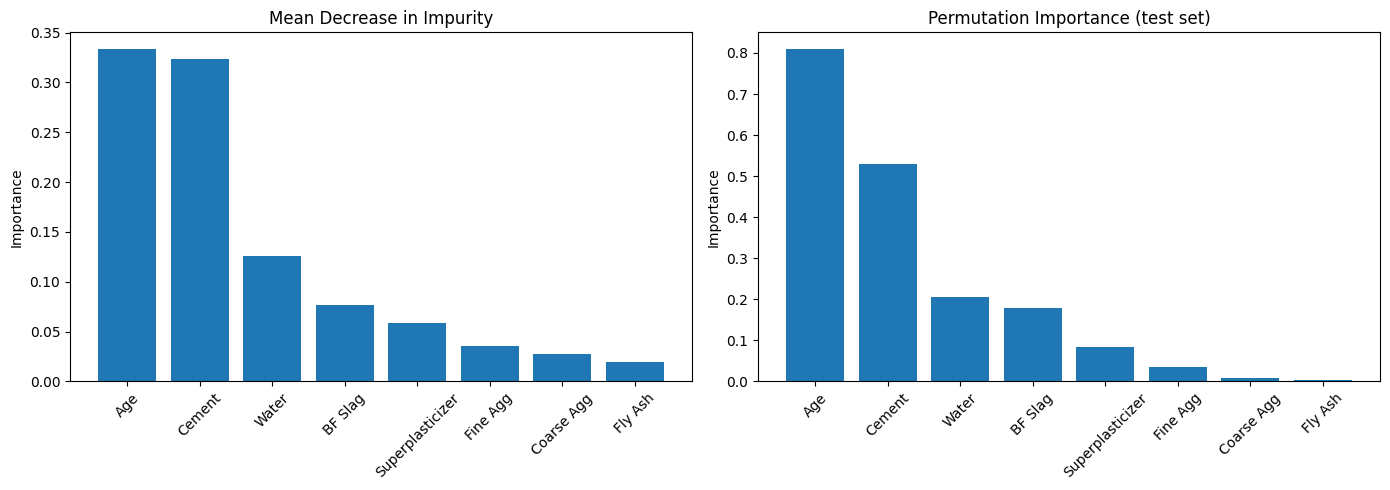

Top 2 features: Age and Cement


In [ ]:
feature_names = labels[:-1] 


mdi = rf.feature_importances_
mdi_idx = np.argsort(-mdi)


perm = permutation_importance(rf, X_test, y_test, n_repeats=10, random_state=42)
perm_idx = np.argsort(-perm.importances_mean)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(len(feature_names)), mdi[mdi_idx])
axes[0].set(xticks=range(len(feature_names)),
            xticklabels=[feature_names[i] for i in mdi_idx],
            title="Mean Decrease in Impurity", ylabel="Importance")
axes[0].tick_params(axis="x", rotation=45)

axes[1].bar(range(len(feature_names)), perm.importances_mean[perm_idx])
axes[1].set(xticks=range(len(feature_names)),
            xticklabels=[feature_names[i] for i in perm_idx],
            title="Permutation Importance (test set)", ylabel="Importance")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

# Top 2 by permutation importance
top2_idx = list(perm_idx[:2])
print(f"Top 2 features: {feature_names[top2_idx[0]]} and {feature_names[top2_idx[1]]}")


## Partial Dependence Analysis

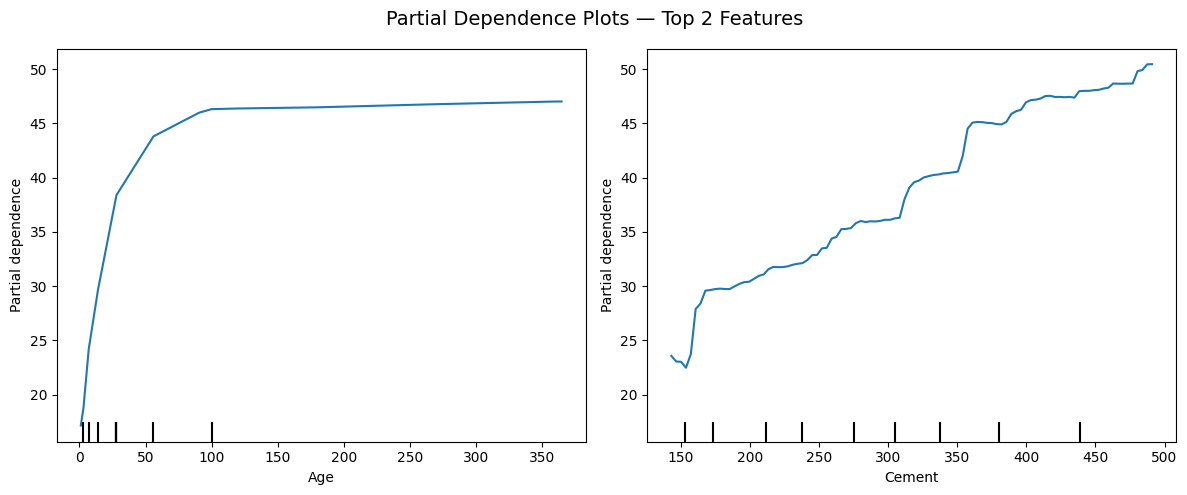

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

PartialDependenceDisplay.from_estimator(
    rf, X_train, features=top2_idx,
    feature_names=feature_names, ax=axes
)

plt.suptitle("Partial Dependence Plots — Top 2 Features", fontsize=14)
plt.tight_layout()
plt.show()
